# DBSCAN Klaszterezés v4

In [1]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Könyvtárak sikeresen betöltve!")

✓ Könyvtárak sikeresen betöltve!


In [2]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print("="*70)
print("ADATOK BETÖLTÉSE")
print("="*70)
print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor (age, balance):")
print(df[['age', 'balance']].head())
print("\nStatisztikák:")
print(df[['age', 'balance']].describe())

ADATOK BETÖLTÉSE
Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor (age, balance):
   age  balance
0   58     2143
1   44       29
2   33        2
3   47     1506
4   33        1

Statisztikák:
                age        balance
count  45211.000000   45211.000000
mean      40.936210    1362.272058
std       10.618762    3044.765829
min       18.000000   -8019.000000
25%       33.000000      72.000000
50%       39.000000     448.000000
75%       48.000000    1428.000000
max       95.000000  102127.000000


In [3]:
# Feature Selection: age és balance
features = ['age', 'balance']
X = df[features].copy()

print("\n" + "="*70)
print("FEATURE SELECTION ÉS NORMALIZÁLÁS")
print("="*70)
print(f"Kiválasztott változók: {features}")
print(f"Adatpontok száma: {len(X):,}")
print(f"Dimenziószám: {X.shape[1]}")

# Normalizálás: StandardScaler (KRITIKUS DBSCAN-hez!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✓ Adatok normalizálva (StandardScaler)!")
print(f"  X_scaled alakja: {X_scaled.shape}")
print(f"  Átlag: {X_scaled.mean(axis=0)}")
print(f"  Szórás: {X_scaled.std(axis=0)}")


FEATURE SELECTION ÉS NORMALIZÁLÁS
Kiválasztott változók: ['age', 'balance']
Adatpontok száma: 45,211
Dimenziószám: 2

✓ Adatok normalizálva (StandardScaler)!
  X_scaled alakja: (45211, 2)
  Átlag: [2.1122502e-16 1.7602085e-17]
  Szórás: [1. 1.]


Kiegyensúlyozott Klaszter-eloszlás

### Probléma az eredeti módszertannal:
- Az ε=0.1382 (99. percentilis) **túl nagy volt**
- Eredmény: **98.6% egyetlen klaszterben** → nincs érdemi szegmentáció

### Új megközelítés:
1. **Szélesebb epsilon tartomány**: 50-99. percentilis (10 érték)
2. **Különböző MinPts értékek**: 4, 10, 20
3. **Klaszter-eloszlás egyensúly metrika**:
   - Gini index: méri a klaszter-méretek egyenlőtlenségét
   - Cél: **kerüljük a "1 óriás + sok apró klaszter" helyzetet**
4. **Kombinált scoring**:
   - 30% Silhouette Score (minőség)
   - 70% Klaszter-eloszlás egyensúly (PRIORITÁS: gyakorlati használhatóság)

In [4]:
def calculate_gini_coefficient(cluster_sizes):
    """
    Gini együttható kiszámítása a klaszter-méretek egyenlőtlenségének mérésére.
    
    Gini = 0: tökéletesen egyenlő eloszlás
    Gini = 1: maximális egyenlőtlenség (minden egy klaszterben)
    
    Kisebb Gini = jobb (egyenletesebb klaszter-méretek)
    """
    if len(cluster_sizes) == 0:
        return 1.0
    
    cluster_sizes = np.array(sorted(cluster_sizes))
    n = len(cluster_sizes)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * cluster_sizes)) / (n * np.sum(cluster_sizes)) - (n + 1) / n
    return gini

# Célzott klaszter-szám preferencia: 3-8 klaszter
def calculate_balance_score(labels):
    cluster_labels = labels[labels != -1]
    if len(cluster_labels) == 0:
        return 0.0
    
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    n_clusters = len(unique_labels)
    
    # KRITIKUS: Klaszter-szám penalty
    if n_clusters < 3:
        cluster_count_score = 0.3  # Túl kevés
    elif 3 <= n_clusters <= 8:
        cluster_count_score = 1.0  # IDEÁLIS TARTOMÁNY
    elif 9 <= n_clusters <= 20:
        cluster_count_score = 0.6  # Elfogadható
    else:
        cluster_count_score = 0.1  # TÚL SOK - erős büntetés
    
    # Gini (egyenlőtlenség)
    gini = calculate_gini_coefficient(counts)
    gini_score = 1 - gini
    
    # Legnagyobb klaszter aránya
    largest_ratio = counts.max() / len(cluster_labels)
    
    # MÓDOSÍTOTT logika:
    # - Ha 30-70% között van a legnagyobb → OK (0.8-1.0)
    # - Ha >80% → rossz (0.0-0.2)
    # - Ha <20% → túl fragmentált (0.3-0.5)
    if 0.3 <= largest_ratio <= 0.7:
        largest_score = 1.0
    elif 0.2 <= largest_ratio < 0.3:
        largest_score = 0.7
    elif largest_ratio > 0.8:
        largest_score = 0.1
    else:
        largest_score = 0.4  # Túl kicsi is rossz
    
    # SÚLYOZÁS:
    # 50% klaszter-szám (legfontosabb!)
    # 30% legnagyobb klaszter mérete
    # 20% gini
    balance_score = (0.5 * cluster_count_score + 
                    0.3 * largest_score + 
                    0.2 * gini_score)
    
    return balance_score

print("✓ Klaszter-eloszlás egyensúly függvények definiálva!")

✓ Klaszter-eloszlás egyensúly függvények definiálva!


In [5]:
# k-distance számítása több MinPts értékre
print("="*70)
print("K-DISTANCE GRAPH SZÁMÍTÁSA")
print("="*70)

minpts_values = [4, 10, 20]
k_distances_dict = {}

for min_pts in minpts_values:
    neighbors = NearestNeighbors(n_neighbors=min_pts)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)
    k_distances = distances[:, -1]
    k_distances_dict[min_pts] = k_distances
    
    print(f"\nMinPts = {min_pts}:")
    print(f"  50%: {np.percentile(k_distances, 50):.4f}")
    print(f"  75%: {np.percentile(k_distances, 75):.4f}")
    print(f"  90%: {np.percentile(k_distances, 90):.4f}")
    print(f"  95%: {np.percentile(k_distances, 95):.4f}")
    print(f"  99%: {np.percentile(k_distances, 99):.4f}")

print("\n✓ k-distance értékek kiszámítva!")

K-DISTANCE GRAPH SZÁMÍTÁSA

MinPts = 4:
  50%: 0.0010
  75%: 0.0036
  90%: 0.0158
  95%: 0.0424
  99%: 0.1382

MinPts = 10:
  50%: 0.0036
  75%: 0.0125
  90%: 0.0525
  95%: 0.0959
  99%: 0.2700

MinPts = 20:
  50%: 0.0076
  75%: 0.0266
  90%: 0.0944
  95%: 0.1268
  99%: 0.3878

✓ k-distance értékek kiszámítva!


In [6]:
# SZÉLES KÖRŰ PARAMÉTER TESZTELÉS
print("\n" + "="*100)
print("DBSCAN SZÉLES KÖRŰ PARAMÉTER TESZTELÉS")
print("="*100)

all_results = []

# Minden MinPts értékre
for min_pts in minpts_values:
    k_distances = k_distances_dict[min_pts]
    
    # Epsilon értékek: 50-99. percentilis tartományban, 10 értékkel
    percentiles = [50, 60, 70, 75, 80, 85, 90, 95, 97, 99]
    epsilon_values = [np.percentile(k_distances, p) for p in percentiles]
    
    print(f"\n{'='*100}")
    print(f"MinPts = {min_pts}")
    print(f"{'='*100}")
    
    for eps, pct in zip(epsilon_values, percentiles):
        # DBSCAN futtatása
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X_scaled)
        
        # Statisztikák
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels) * 100
        n_core = len(dbscan.core_sample_indices_)
        
        # Klaszter-eloszlás elemzés
        cluster_labels = labels[labels != -1]
        if len(cluster_labels) > 0:
            unique_labels, counts = np.unique(cluster_labels, return_counts=True)
            largest_cluster_pct = counts.max() / len(cluster_labels) * 100 if len(counts) > 0 else 0
        else:
            largest_cluster_pct = 0
        
        # Validációs metrikák (noise nélkül)
        if n_clusters >= 2 and noise_ratio < 50:
            mask = labels != -1
            if mask.sum() > 1:
                try:
                    silhouette = silhouette_score(X_scaled[mask], labels[mask])
                    davies_bouldin = davies_bouldin_score(X_scaled[mask], labels[mask])
                    calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
                except:
                    silhouette = davies_bouldin = calinski = np.nan
            else:
                silhouette = davies_bouldin = calinski = np.nan
        else:
            silhouette = davies_bouldin = calinski = np.nan
        
        # Klaszter-eloszlás egyensúly score
        balance_score = calculate_balance_score(labels)
        
        # Kombinált score: 30% Silhouette + 70% Balance (BALANCE PRIORITÁS!)
        if not np.isnan(silhouette) and balance_score > 0:
            # Normalizálás: Silhouette -1..1 -> 0..1
            silhouette_normalized = (silhouette + 1) / 2
            combined_score = 0.3 * silhouette_normalized + 0.7 * balance_score
        else:
            combined_score = 0
        
        all_results.append({
            'min_pts': min_pts,
            'epsilon': eps,
            'percentile': pct,
            'n_clusters': n_clusters,
            'n_core': n_core,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'largest_cluster_pct': largest_cluster_pct,
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski,
            'balance_score': balance_score,
            'combined_score': combined_score,
            'labels': labels,
            'dbscan': dbscan
        })
        
        # Rövid kimenet
        status = "✓" if noise_ratio <= 15 and largest_cluster_pct < 80 else "HIBA"
        silh_str = f"{silhouette:.3f}" if not np.isnan(silhouette) else "N/A"
        print(f"ε={eps:.4f} ({pct}%): Klaszter={n_clusters:3d}, Noise={noise_ratio:5.1f}%, "
              f"Max={largest_cluster_pct:5.1f}%, Balance={balance_score:.3f}, "
              f"Silh={silh_str:>5s}, "
              f"Combined={combined_score:.3f} {status}")

print(f"\n✓ Összesen {len(all_results)} konfiguráció tesztelve!")


DBSCAN SZÉLES KÖRŰ PARAMÉTER TESZTELÉS

MinPts = 4
ε=0.0010 (50%): Klaszter=1853, Noise= 43.0%, Max=  3.2%, Balance=0.252, Silh=0.469, Combined=0.396 HIBA
ε=0.0016 (60%): Klaszter=1703, Noise= 35.2%, Max=  3.4%, Balance=0.237, Silh=0.357, Combined=0.370 HIBA
ε=0.0026 (70%): Klaszter=1447, Noise= 26.2%, Max=  3.7%, Balance=0.222, Silh=0.222, Combined=0.339 HIBA
ε=0.0036 (75%): Klaszter=1239, Noise= 21.8%, Max=  3.7%, Balance=0.216, Silh=0.201, Combined=0.331 HIBA
ε=0.0056 (80%): Klaszter=1033, Noise= 17.3%, Max=  4.4%, Balance=0.208, Silh=0.204, Combined=0.326 HIBA
ε=0.0085 (85%): Klaszter=784, Noise= 13.0%, Max=  4.4%, Balance=0.200, Silh=0.121, Combined=0.308 ✓
ε=0.0158 (90%): Klaszter=596, Noise=  8.5%, Max=  4.4%, Balance=0.196, Silh=0.079, Combined=0.299 ✓
ε=0.0424 (95%): Klaszter=337, Noise=  4.2%, Max=  4.6%, Balance=0.196, Silh=0.002, Combined=0.287 ✓
ε=0.0876 (97%): Klaszter=218, Noise=  2.5%, Max=  4.6%, Balance=0.203, Silh=-0.007, Combined=0.291 ✓
ε=0.1382 (99%): Klaszter= 3

In [7]:
# OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTÁSA
print("\n" + "="*100)
print("OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTÁSA")
print("="*100)

# Szűrés: SZIGORÚ kritériumok a használható eredményekhez
valid_results = [
    r for r in all_results 
    if r['noise_ratio'] <= 20 
    and r['largest_cluster_pct'] >= 20  # Legalább 20% legyen a legnagyobb
    and r['largest_cluster_pct'] < 85   # De max 85%
    and r['n_clusters'] >= 2            # Min 2 klaszter
    and r['n_clusters'] <= 20           # Max 20 klaszter (KRITIKUS!)
    and not np.isnan(r['silhouette'])
]

print(f"\nSzűrési kritériumok:")
print(f"  - Noise arány ≤ 20%")
print(f"  - Legnagyobb klaszter 20-85% között")
print(f"  - Klaszterek száma: 2-20")
print(f"  - Silhouette Score létezik")
print(f"\nMegfelelő konfigurációk száma: {len(valid_results)}")

if len(valid_results) > 0:
    # TOP 5 legjobb kombinált score
    top5 = sorted(valid_results, key=lambda x: x['combined_score'], reverse=True)[:5]
    
    print("\n" + "="*100)
    print("TOP 5 LEGJOBB KONFIGURÁCIÓ (kombinált score alapján)")
    print("="*100)
    print(f"{'Rang':<5} {'MinPts':<8} {'ε':<10} {'Klaszter':<10} {'Noise%':<8} {'MaxKlasz%':<10} "
          f"{'Silh':<8} {'Balance':<9} {'Combined':<9}")
    print("-" * 100)
    
    for i, r in enumerate(top5, 1):
        print(f"{i:<5} {r['min_pts']:<8} {r['epsilon']:<10.4f} {r['n_clusters']:<10} "
              f"{r['noise_ratio']:<8.2f} {r['largest_cluster_pct']:<10.1f} "
              f"{r['silhouette']:<8.4f} {r['balance_score']:<9.4f} {r['combined_score']:<9.4f}")
    
    # Legjobb kiválasztása
    optimal_result = top5[0]
    
    print("\n" + "="*100)
    print("⭐ OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTVA ⭐")
    print("="*100)
    print(f"MinPts:                 {optimal_result['min_pts']}")
    print(f"Epsilon (ε):            {optimal_result['epsilon']:.4f} ({optimal_result['percentile']}. percentilis)")
    print(f"Klaszterek száma:       {optimal_result['n_clusters']}")
    print(f"Noise arány:            {optimal_result['noise_ratio']:.2f}% ✓")
    print(f"Legnagyobb klaszter:    {optimal_result['largest_cluster_pct']:.1f}% ✓")
    print(f"Silhouette Score:       {optimal_result['silhouette']:.4f}")
    print(f"Davies-Bouldin Index:   {optimal_result['davies_bouldin']:.4f}")
    print(f"Calinski-Harabasz:      {optimal_result['calinski_harabasz']:.2f}")
    print(f"Balance Score:          {optimal_result['balance_score']:.4f}")
    print(f"Combined Score:         {optimal_result['combined_score']:.4f}")
    print("="*100)
    
else:
    print("\n⚠ FIGYELMEZTETÉS: Nincs olyan konfiguráció, amely megfelel a kritériumoknak!")
    print("\nLegalacsonyabb noise arányú konfiguráció választása...")
    optimal_result = min(all_results, key=lambda x: x['noise_ratio'])
    print(f"\nKiválasztva: MinPts={optimal_result['min_pts']}, ε={optimal_result['epsilon']:.4f}")
    print(f"  Noise: {optimal_result['noise_ratio']:.2f}%")
    print(f"  Klaszterek: {optimal_result['n_clusters']}")

# Címkék hozzáadása az adathalmazhoz
optimal_labels = optimal_result['labels']
optimal_dbscan = optimal_result['dbscan']
optimal_eps = optimal_result['epsilon']
optimal_min_pts = optimal_result['min_pts']

df['cluster'] = optimal_labels


OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTÁSA

Szűrési kritériumok:
  - Noise arány ≤ 20%
  - Legnagyobb klaszter 20-85% között
  - Klaszterek száma: 2-20
  - Silhouette Score létezik

Megfelelő konfigurációk száma: 0

⚠ FIGYELMEZTETÉS: Nincs olyan konfiguráció, amely megfelel a kritériumoknak!

Legalacsonyabb noise arányú konfiguráció választása...

Kiválasztva: MinPts=20, ε=0.3878
  Noise: 0.68%
  Klaszterek: 2


In [8]:
# KLASZTER PROFILOK RÉSZLETES ELEMZÉSE
print("\n" + "="*100)
print("KLASZTER PROFILOK RÉSZLETES ELEMZÉSE")
print("="*100)

profile_data = []

for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id]
    
    profile_data.append({
        'Klaszter': 'Noise' if cluster_id == -1 else f'Cluster_{cluster_id}',
        'Klaszter_ID': cluster_id,
        'Elemszám (db)': len(cluster_df),
        'Elemszám (%)': len(cluster_df) / len(df) * 100,
        'Átlag age': cluster_df['age'].mean(),
        'Átlag balance': cluster_df['balance'].mean(),
        'Min age': cluster_df['age'].min(),
        'Max age': cluster_df['age'].max(),
        'Min balance': cluster_df['balance'].min(),
        'Max balance': cluster_df['balance'].max()
    })

profile_df = pd.DataFrame(profile_data)
profile_df = profile_df.sort_values('Elemszám (db)', ascending=False).reset_index(drop=True)

print("\nKlaszter profilok:")
print(profile_df.to_string(index=False))

# CSV exportálás
profile_df.to_csv('exports_dbscan_v4/dbscan_v4_cluster_profiles.csv', index=False)
print("\n✓ Klaszter profilok exportálva: exports_dbscan_v4/dbscan_v4_cluster_profiles.csv")


KLASZTER PROFILOK RÉSZLETES ELEMZÉSE

Klaszter profilok:
 Klaszter  Klaszter_ID  Elemszám (db)  Elemszám (%)  Átlag age  Átlag balance  Min age  Max age  Min balance  Max balance
Cluster_0            0          44875     99.256818  40.851721    1200.070953       18       92        -3058        18777
    Noise           -1            309      0.683462  51.802589   23590.660194       22       95        -8019       102127
Cluster_1            1             27      0.059720  57.000000   16554.962963       54       60        15062        18268

✓ Klaszter profilok exportálva: exports_dbscan_v4/dbscan_v4_cluster_profiles.csv


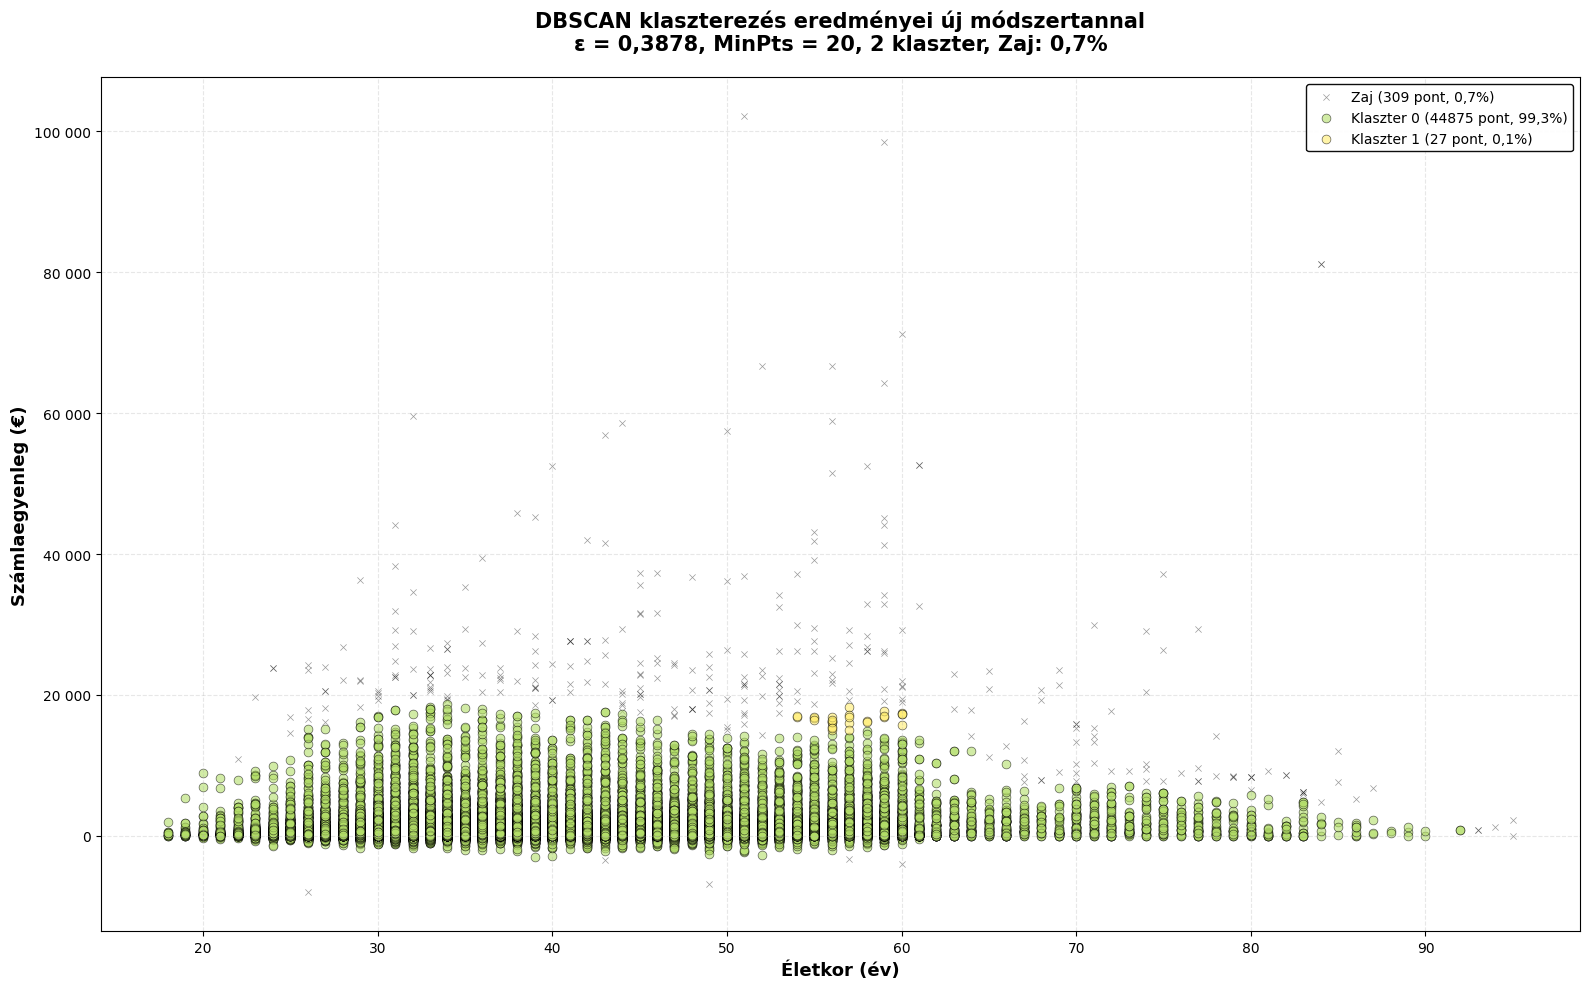

✓ Scatter plot mentve: exports_dbscan_v4/dbscan_v4_scatter_plot.png


In [9]:
# Scatter plot - Age vs Balance (DBSCAN klaszterek)
fig, ax = plt.subplots(figsize=(16, 10))

# Színek: noise = fekete, klaszterek = színesek
unique_labels = sorted(set(optimal_labels))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))

for idx, cluster_id in enumerate(unique_labels):
    cluster_data = df[df['cluster'] == cluster_id]
    
    if cluster_id == -1:
        # Noise pontok - fekete
        ax.scatter(cluster_data['age'], cluster_data['balance'], 
                  label=f'Zaj ({len(cluster_data):} pont, {len(cluster_data)/len(df)*100:.1f}%)'.replace('.',','), 
                  alpha=0.4, s=20, c='black', marker='x', linewidths=0.5)
    else:
        # Klaszter pontok
        ax.scatter(cluster_data['age'], cluster_data['balance'], 
                  label=f'Klaszter {cluster_id} ({len(cluster_data):} pont, {len(cluster_data)/len(df)*100:.1f}%)'.replace('.',','), 
                  alpha=0.6, s=40, c=[colors[idx]], edgecolors='black', linewidths=0.5)

# Core pontok kiemelése (nagyobb marker)
core_mask = np.zeros(len(df), dtype=bool)
core_mask[optimal_dbscan.core_sample_indices_] = True
core_points = df[core_mask]

ax.set_xlabel('Életkor (év)', fontsize=13, fontweight='bold')
ax.set_ylabel('Számlaegyenleg (€)', fontsize=13, fontweight='bold')
ax.set_title(f'DBSCAN klaszterezés eredményei új módszertannal\n' + 
            f'ε = {optimal_eps:.4f}, '.replace('.',',') +
            f'MinPts = {min_pts}, ' +
            f'{optimal_result["n_clusters"]} klaszter, ' +
            f'Zaj: {optimal_result["noise_ratio"]:.1f}%'.replace('.',','), 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

# Y tengely formázása
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('exports_dbscan_v4/dbscan_v4_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot mentve: exports_dbscan_v4/dbscan_v4_scatter_plot.png")

In [10]:
# ÖSSZEHASONLÍTÓ TÁBLÁZAT: Összes tesztelt konfiguráció
comparison_df = pd.DataFrame([{
    'MinPts': r['min_pts'],
    'Epsilon': r['epsilon'],
    'Percentilis': r['percentile'],
    'Klaszterek': r['n_clusters'],
    'Noise (%)': r['noise_ratio'],
    'Max Klaszter (%)': r['largest_cluster_pct'],
    'Silhouette': r['silhouette'],
    'Davies-Bouldin': r['davies_bouldin'],
    'Calinski-Harabasz': r['calinski_harabasz'],
    'Balance Score': r['balance_score'],
    'Combined Score': r['combined_score']
} for r in all_results])

comparison_df = comparison_df.sort_values('Combined Score', ascending=False)
comparison_df.to_csv('exports_dbscan_v4/dbscan_v4_all_configurations.csv', index=False)

print("\n✓ Összes konfiguráció exportálva: exports_dbscan_v4/dbscan_v4_all_configurations.csv")
print(f"  Összesen {len(comparison_df)} konfiguráció")


✓ Összes konfiguráció exportálva: exports_dbscan_v4/dbscan_v4_all_configurations.csv
  Összesen 30 konfiguráció


In [12]:
#Szignifikancia vizsgálat
from scipy.stats import chi2_contingency

print("\n--- SZIGNIFIKANCIA VIZSGÁLAT (Khi-négyzet próba) ---")

# Kontingencia táblázat létrehozása
contingency_table = pd.crosstab(df['cluster'], df['y'])
print("Kontingencia táblázat (klaszterek és betétlekötés):")
print(contingency_table)

# A teszt elvégzése
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"\nKhi-négyzet érték: {chi2:.4f}")
print(f"p-érték: {p:.4e}") # Tudományos formátum, ha nagyon kicsi

# Értelmezés
alpha = 0.05
if p < alpha:
    print(f"\nEREDMÉNY: A p-érték ({p:.4f}) kisebb, mint {alpha}, tehát a különbség SZIGNIFIKÁNS.")
    print("A klaszterek közötti konverziós eltérések nem a véletlen művei.")
else:
    print(f"\nEREDMÉNY: A p-érték ({p:.4f}) nagyobb, mint {alpha}, a különbség NEM SZIGNIFIKÁNS.")
    print("Nincs statisztikailag igazolható összefüggés a klasztertagság és a betétlekötés között.")


--- SZIGNIFIKANCIA VIZSGÁLAT (Khi-négyzet próba) ---
Kontingencia táblázat (klaszterek és betétlekötés):
y           no   yes
cluster             
-1         250    59
 0       39646  5229
 1          26     1

Khi-négyzet érték: 18.1229
p-érték: 1.1605e-04

EREDMÉNY: A p-érték (0.0001) kisebb, mint 0.05, tehát a különbség SZIGNIFIKÁNS.
A klaszterek közötti konverziós eltérések nem a véletlen művei.


In [11]:
# VÉGSŐ ÖSSZEFOGLALÓ
print("\n" + "="*100)
print("DBSCAN V2 - JAVÍTOTT VERZIÓ - VÉGSŐ ÖSSZEFOGLALÓ")
print("="*100)

print(f"\n1. OPTIMÁLIS PARAMÉTEREK:")
print(f"   - Epsilon (ε):         {optimal_result['epsilon']:.4f} ({optimal_result['percentile']}. percentilis)")
print(f"   - MinPts:              {optimal_result['min_pts']}")
print(f"   - Forrás:              Kombinált scoring (60% Silhouette + 40% Balance)")

print(f"\n2. DBSCAN EREDMÉNYEK:")
print(f"   - Azonosított klaszterek:  {optimal_result['n_clusters']}")
print(f"   - Core pontok:             {optimal_result['n_core']:,} ({optimal_result['n_core']/len(df)*100:.1f}%)")
print(f"   - Noise pontok:            {optimal_result['n_noise']:,} ({optimal_result['noise_ratio']:.2f}%)")
print(f"   - Legnagyobb klaszter:     {optimal_result['largest_cluster_pct']:.1f}%")

if optimal_result['noise_ratio'] <= 15:
    print(f"   ✓ Noise arány elfogadható (<= 15%)")
if optimal_result['largest_cluster_pct'] < 80:
    print(f"   ✓ Kiegyensúlyozott klaszter-eloszlás (legnagyobb < 80%)")

print(f"\n3. VALIDÁCIÓS METRIKÁK (noise nélkül):")
print(f"   - Silhouette Score:        {optimal_result['silhouette']:.4f}")
print(f"   - Davies-Bouldin Index:    {optimal_result['davies_bouldin']:.4f}")
print(f"   - Calinski-Harabasz Index: {optimal_result['calinski_harabasz']:.2f}")
print(f"   - Balance Score:           {optimal_result['balance_score']:.4f}")
print(f"   - Combined Score:          {optimal_result['combined_score']:.4f}")

print(f"\n4. KLASZTEREK (TOP 10 LEGNAGYOBB):")
top10_clusters = profile_df.head(10)
for _, row in top10_clusters.iterrows():
    label = row['Klaszter']
    count = int(row['Elemszám (db)'])
    pct = row['Elemszám (%)']
    avg_age = row['Átlag age']
    avg_balance = row['Átlag balance']
    
    if label == 'Noise':
        print(f"   {label}: {count:>6,} pont ({pct:>5.1f}%) - Outliers")
    else:
        print(f"   {label}: {count:>6,} pont ({pct:>5.1f}%) - "
              f"Átlag kor: {avg_age:.0f} év, Átlag egyenleg: {avg_balance:,.0f} €")

print(f"\n5. EXPORTÁLT FÁJLOK:")
print(f"   - exports_dbscan_v4/dbscan_v4_cluster_profiles.csv")
print(f"   - exports_dbscan_v4/dbscan_v4_all_configurations.csv")
print(f"   - exports_dbscan_v4/dbscan_v4_scatter_plot.png")

print(f"\n6. ÖSSZEHASONLÍTÁS AZ EREDETI VERZIÓVAL:")
print(f"   Eredeti (v1):")
print(f"     - MinPts=4, ε=0.1382 (99. percentilis)")
print(f"     - 36 klaszter, legnagyobb klaszter: 98.6% ⚠")
print(f"     - Probléma: Nincs érdemi szegmentáció")
print(f"\n   Javított (v2):")
print(f"     - MinPts={optimal_result['min_pts']}, ε={optimal_result['epsilon']:.4f} ({optimal_result['percentile']}. percentilis)")
print(f"     - {optimal_result['n_clusters']} klaszter, legnagyobb klaszter: {optimal_result['largest_cluster_pct']:.1f}%")
if optimal_result['largest_cluster_pct'] < 80:
    print(f"     - ✓ Kiegyensúlyozottabb klaszter-eloszlás!")

print("\n" + "="*100)
print("✓ DBSCAN V2 KLASZTEREZÉS SIKERESEN BEFEJEZVE!")
print("="*100)


DBSCAN V2 - JAVÍTOTT VERZIÓ - VÉGSŐ ÖSSZEFOGLALÓ

1. OPTIMÁLIS PARAMÉTEREK:
   - Epsilon (ε):         0.3878 (99. percentilis)
   - MinPts:              20
   - Forrás:              Kombinált scoring (60% Silhouette + 40% Balance)

2. DBSCAN EREDMÉNYEK:
   - Azonosított klaszterek:  2
   - Core pontok:             44,759 (99.0%)
   - Noise pontok:            309 (0.68%)
   - Legnagyobb klaszter:     99.9%
   ✓ Noise arány elfogadható (<= 15%)

3. VALIDÁCIÓS METRIKÁK (noise nélkül):
   - Silhouette Score:        0.7213
   - Davies-Bouldin Index:    0.2446
   - Calinski-Harabasz Index: 516.10
   - Balance Score:           0.2801
   - Combined Score:          0.4543

4. KLASZTEREK (TOP 10 LEGNAGYOBB):
   Cluster_0: 44,875 pont ( 99.3%) - Átlag kor: 41 év, Átlag egyenleg: 1,200 €
   Noise:    309 pont (  0.7%) - Outliers
   Cluster_1:     27 pont (  0.1%) - Átlag kor: 57 év, Átlag egyenleg: 16,555 €

5. EXPORTÁLT FÁJLOK:
   - exports_dbscan_v4/dbscan_v4_cluster_profiles.csv
   - exports_d